<a href="https://colab.research.google.com/github/MarlzRana/machine-learning/blob/main/non_temp_model_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import math

In [ ]:
def truncate_to_three_decimal_places(num):
    # Convert the number to a string
    num_str = str(num)
    # Split the string on the decimal point
    parts = num_str.split('.')
    # If the number is a float and has a decimal part
    if len(parts) > 1:
        decimal_part = parts[1]
        # Truncate the decimal part to three characters if longer, or pad if shorter
        truncated_decimal = (decimal_part + "000")[:3]  # Add zeros and then truncate to ensure length
        # Reassemble the number with the truncated decimal part
        truncated_num_str = parts[0] + '.' + truncated_decimal
    else:
        # If there is no decimal part, add '.000'
        truncated_num_str = parts[0] + '.000'

    return truncated_num_str


def round_up_third_decimal(num):
    # Scale the number to keep three decimal places as a whole number
    scaled_num = num * 1000
    # Apply math.ceil to round up the number
    rounded_num = math.ceil(scaled_num)
    # Scale back to the original number of decimal places
    final_num = rounded_num / 1000
    # Convert the number to a string
    final_num_str = f"{final_num:.3f}"  # Ensures at least three decimal places
    return final_num_str

In [ ]:
df_res = pd.read_csv("/content/drive/My Drive/3yp/results/non_sequential_results.csv")

In [ ]:
df_res

,model_name,overall_iou,overall_dice_coefficient,mean_iou,mean_dice_coefficient,0_iou_road,0_dice_coefficient_road,1_iou_sidewalk,1_dice_coefficient_sidewalk,2_iou_human,...,3_iou_vehicle,3_dice_coefficient_vehicle,4_iou_object,4_dice_coefficient_object,5_iou_construction,5_dice_coefficient_construction,6_iou_nature,6_dice_coefficient_nature,7_iou_sky,7_dice_coefficient_sky
0,pretrain_modresnet18_unet,0.812338,0.896139,0.705683,0.810259,0.889403,0.940878,0.590588,0.737104,0.543032,...,0.822299,0.901377,0.349382,0.515704,0.751601,0.857167,0.795080,0.885070,0.904078,0.948522
1,pretrain_resnet18_unet,0.775502,0.873171,0.651226,0.763223,0.874817,0.932664,0.537247,0.692984,0.427954,...,0.781294,0.875617,0.250008,0.397894,0.709667,0.828899,0.746920,0.853542,0.881897,0.935820
2,pretrain_modresnet34_unet,0.816200,0.898482,0.712178,0.815168,0.891338,0.941903,0.604862,0.748498,0.553110,...,0.829715,0.905826,0.356400,0.523649,0.753791,0.858559,0.797358,0.886407,0.910855,0.952518
3,pretrain_resnet34_unet,0.790055,0.882397,0.665110,0.774346,0.882870,0.937205,0.554152,0.707637,0.441187,...,0.795466,0.884719,0.263752,0.415396,0.726709,0.840674,0.763991,0.864910,0.892754,0.942351
4,pretrain_modresnet50_unet,0.807677,0.892972,0.696435,0.799405,0.885606,0.938122,0.582357,0.723952,0.500179,...,0.818717,0.897762,0.349980,0.514063,0.743817,0.851280,0.790104,0.880615,0.900722,0.945266
5,pretrain_resnet50_unet,0.806479,0.892370,0.677240,0.779440,0.891634,0.941708,0.570748,0.713496,0.419958,...,0.815727,0.896235,0.292658,0.448150,0.743784,0.851527,0.780184,0.874661,0.903226,0.947450
6,mod_unet,0.778580,0.874712,0.658269,0.768179,0.866674,0.927232,0.530385,0.678829,0.438496,...,0.778573,0.872389,0.301173,0.458705,0.705996,0.825367,0.760483,0.861404,0.884369,0.936191


In [ ]:
df_res.loc[df_res['model_name'] == 'mod_unet', 'model_name'] = 'U-Net'


df_res.loc[df_res['model_name'] == 'pretrain_resnet18_unet', 'model_name'] = 'ResNet18-U-Net-A'
df_res.loc[df_res['model_name'] == 'pretrain_modresnet18_unet', 'model_name'] = 'ResNet18-U-Net-B'

df_res.loc[df_res['model_name'] == 'pretrain_resnet34_unet', 'model_name'] = 'ResNet34-U-Net-A'
df_res.loc[df_res['model_name'] == 'pretrain_modresnet34_unet', 'model_name'] = 'ResNet34-U-Net-B'

df_res.loc[df_res['model_name'] == 'pretrain_resnet50_unet', 'model_name'] = 'ResNet50-U-Net-A'
df_res.loc[df_res['model_name'] == 'pretrain_modresnet50_unet', 'model_name'] = 'ResNet50-U-Net-B'

df_res["runtime"] = [91.739, 41.227, 127.540, 52.019, 605.152, 170.841, 63.520]


In [ ]:
# Create a new index for swapping
n = len(df_res)
new_index = list(range(n))
new_index[0], new_index[1] = new_index[1], new_index[0]
new_index[2], new_index[3] = new_index[3], new_index[2]
new_index[4], new_index[5] = new_index[5], new_index[4]

# Shift the last row to the first
last_row = new_index.pop(-1)
new_index.insert(0, last_row)

# Reindex the DataFrame
df_res = df_res.reindex(new_index)
df_res.reset_index(drop=True, inplace=True)

In [ ]:
df_res

,model_name,overall_iou,overall_dice_coefficient,mean_iou,mean_dice_coefficient,0_iou_road,0_dice_coefficient_road,1_iou_sidewalk,1_dice_coefficient_sidewalk,2_iou_human,...,3_dice_coefficient_vehicle,4_iou_object,4_dice_coefficient_object,5_iou_construction,5_dice_coefficient_construction,6_iou_nature,6_dice_coefficient_nature,7_iou_sky,7_dice_coefficient_sky,runtime
0,U-Net,0.778580,0.874712,0.658269,0.768179,0.866674,0.927232,0.530385,0.678829,0.438496,...,0.872389,0.301173,0.458705,0.705996,0.825367,0.760483,0.861404,0.884369,0.936191,63.520
1,ResNet18-U-Net-A,0.775502,0.873171,0.651226,0.763223,0.874817,0.932664,0.537247,0.692984,0.427954,...,0.875617,0.250008,0.397894,0.709667,0.828899,0.746920,0.853542,0.881897,0.935820,41.227
2,ResNet18-U-Net-B,0.812338,0.896139,0.705683,0.810259,0.889403,0.940878,0.590588,0.737104,0.543032,...,0.901377,0.349382,0.515704,0.751601,0.857167,0.795080,0.885070,0.904078,0.948522,91.739
3,ResNet34-U-Net-A,0.790055,0.882397,0.665110,0.774346,0.882870,0.937205,0.554152,0.707637,0.441187,...,0.884719,0.263752,0.415396,0.726709,0.840674,0.763991,0.864910,0.892754,0.942351,52.019
4,ResNet34-U-Net-B,0.816200,0.898482,0.712178,0.815168,0.891338,0.941903,0.604862,0.748498,0.553110,...,0.905826,0.356400,0.523649,0.753791,0.858559,0.797358,0.886407,0.910855,0.952518,127.540
5,ResNet50-U-Net-A,0.806479,0.892370,0.677240,0.779440,0.891634,0.941708,0.570748,0.713496,0.419958,...,0.896235,0.292658,0.448150,0.743784,0.851527,0.780184,0.874661,0.903226,0.947450,170.841
6,ResNet50-U-Net-B,0.807677,0.892972,0.696435,0.799405,0.885606,0.938122,0.582357,0.723952,0.500179,...,0.897762,0.349980,0.514063,0.743817,0.851280,0.790104,0.880615,0.900722,0.945266,605.152


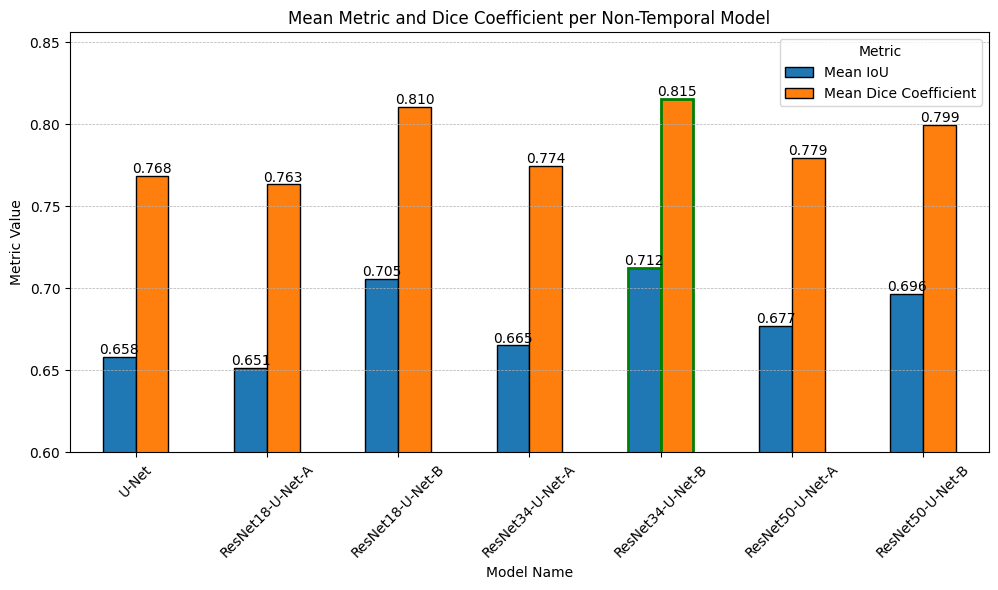

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_res contains your data
# Find the row with the maximum IoU and Dice coefficient
best_iou_index = df_res['mean_iou'].idxmax()
best_dice_index = df_res['mean_dice_coefficient'].idxmax()

# Plot the bar chart
ax = df_res.plot(x="model_name", y=["mean_iou", "mean_dice_coefficient"], kind="bar", figsize=(10, 6))

# Highlight the bars with the best IoU and Dice coefficient by setting the edge color
for i, bar in enumerate(ax.patches):
    if i == best_iou_index or i == best_dice_index + len(df_res):
        bar.set_edgecolor('green')
        bar.set_linewidth(2)  # Adjust border width as needed
    else:
        bar.set_edgecolor('black')  # Set edge color for other bars

# Add title, labels, grid, and legend
plt.title("Mean Metric and Dice Coefficient per Non-Temporal Model")
plt.xlabel("Model Name")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)  # Only horizontal grid lines
plt.tight_layout()
plt.legend(["Mean IoU", "Mean Dice Coefficient"], title='Metric')

ax.set_ylim(bottom=0.6)

# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(f"{truncate_to_three_decimal_places(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', rotation=0, xytext=(0, 5),
                textcoords='offset points')

plt.show()


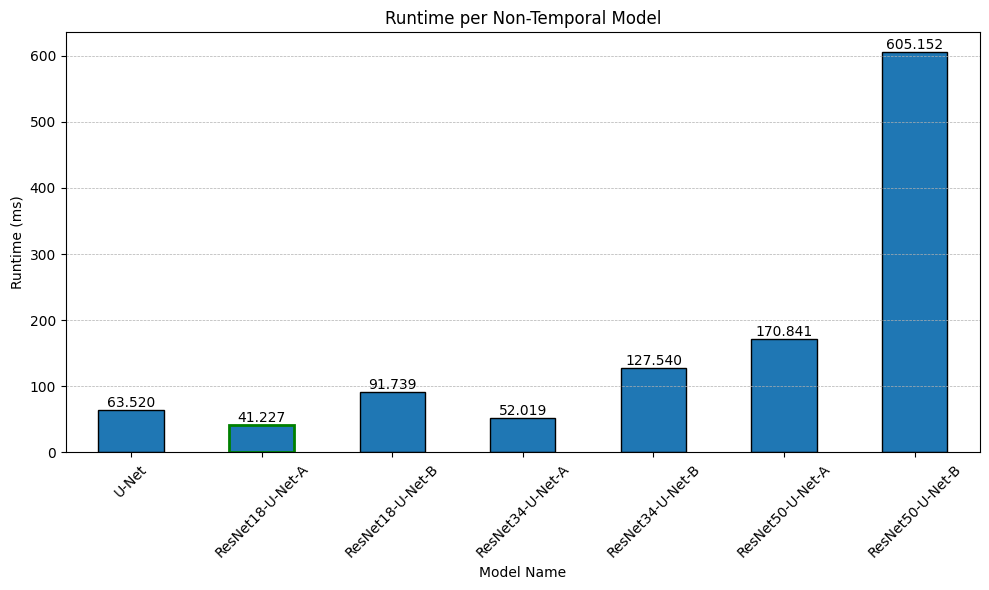

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_res contains your data
# Find the row with the minimum runtime
best_index = df_res['runtime'].idxmin()

# Plot the bar chart
ax = df_res.plot(x="model_name", y=["runtime"], kind="bar", figsize=(10, 6), legend=None)

# Highlight the bar with the best runtime by setting the edge color
for i, bar in enumerate(ax.patches):
    if i == best_index:
        bar.set_edgecolor('green')
        bar.set_linewidth(2)  # Adjust border width as needed
    else:
        bar.set_edgecolor('black')  # Set edge color for other bars

# Add title, labels, grid, and legend
plt.title("Runtime per Non-Temporal Model")
plt.xlabel("Model Name")
plt.ylabel("Runtime (ms)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)  # Only horizontal grid lines
plt.tight_layout()

# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(f"{round_up_third_decimal(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', rotation=0, xytext=(0, 5),
                textcoords='offset points')

plt.show()


In [ ]:
df_res_without_unet = df_res.iloc[1:]

In [ ]:
df_res_without_unet["model_depth"] = df_res_without_unet['model_name'].apply(lambda x: int(x.split('-')[0][-2:]))
df_res_without_unet["strat"] = df_res_without_unet['model_name'].apply(lambda x: x[-1:])#
df_res_without_unet

<ipython-input-10-d3178159f207>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res_without_unet["model_depth"] = df_res_without_unet['model_name'].apply(lambda x: int(x.split('-')[0][-2:]))
<ipython-input-10-d3178159f207>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res_without_unet["strat"] = df_res_without_unet['model_name'].apply(lambda x: x[-1:])#


,model_name,overall_iou,overall_dice_coefficient,mean_iou,mean_dice_coefficient,0_iou_road,0_dice_coefficient_road,1_iou_sidewalk,1_dice_coefficient_sidewalk,2_iou_human,...,4_dice_coefficient_object,5_iou_construction,5_dice_coefficient_construction,6_iou_nature,6_dice_coefficient_nature,7_iou_sky,7_dice_coefficient_sky,runtime,model_depth,strat
1,ResNet18-U-Net-A,0.775502,0.873171,0.651226,0.763223,0.874817,0.932664,0.537247,0.692984,0.427954,...,0.397894,0.709667,0.828899,0.746920,0.853542,0.881897,0.935820,41.227,18,A
2,ResNet18-U-Net-B,0.812338,0.896139,0.705683,0.810259,0.889403,0.940878,0.590588,0.737104,0.543032,...,0.515704,0.751601,0.857167,0.795080,0.885070,0.904078,0.948522,91.739,18,B
3,ResNet34-U-Net-A,0.790055,0.882397,0.665110,0.774346,0.882870,0.937205,0.554152,0.707637,0.441187,...,0.415396,0.726709,0.840674,0.763991,0.864910,0.892754,0.942351,52.019,34,A
4,ResNet34-U-Net-B,0.816200,0.898482,0.712178,0.815168,0.891338,0.941903,0.604862,0.748498,0.553110,...,0.523649,0.753791,0.858559,0.797358,0.886407,0.910855,0.952518,127.540,34,B
5,ResNet50-U-Net-A,0.806479,0.892370,0.677240,0.779440,0.891634,0.941708,0.570748,0.713496,0.419958,...,0.448150,0.743784,0.851527,0.780184,0.874661,0.903226,0.947450,170.841,50,A
6,ResNet50-U-Net-B,0.807677,0.892972,0.696435,0.799405,0.885606,0.938122,0.582357,0.723952,0.500179,...,0.514063,0.743817,0.851280,0.790104,0.880615,0.900722,0.945266,605.152,50,B


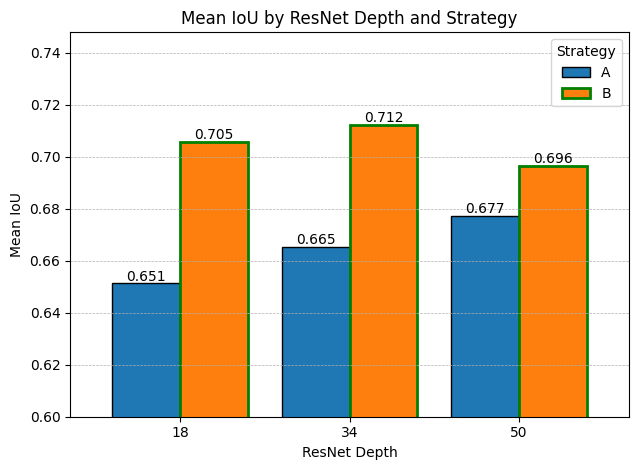

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data creation (you would replace this with your data loading code)

# Pivot the DataFrame to get strategies as columns
pivot_df = df_res_without_unet.pivot(index='model_depth', columns='strat', values='mean_iou')

# Plotting
ax = pivot_df.plot(kind='bar', width=0.8)

# Highlight the bar with the best IoU by setting the edge color
for i, bar in enumerate(ax.patches):
    if i in [3, 4, 5]:
        bar.set_edgecolor('green')
        bar.set_linewidth(2)  # Adjust border width as needed
    else:
        bar.set_edgecolor('black')  # Set edge color for other bars

plt.xlabel('ResNet Depth')
plt.ylabel('Mean IoU')
plt.title('Mean IoU by ResNet Depth and Strategy')
plt.xticks(rotation=0)  # Rotates labels to be horizontal
plt.legend(title='Strategy')
plt.tight_layout()

# Set y-axis starting point to 0.5
ax.set_ylim(bottom=0.6)

# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(f"{truncate_to_three_decimal_places(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', rotation=0, xytext=(0, 5),
                textcoords='offset points')

# Show the plot
plt.show()


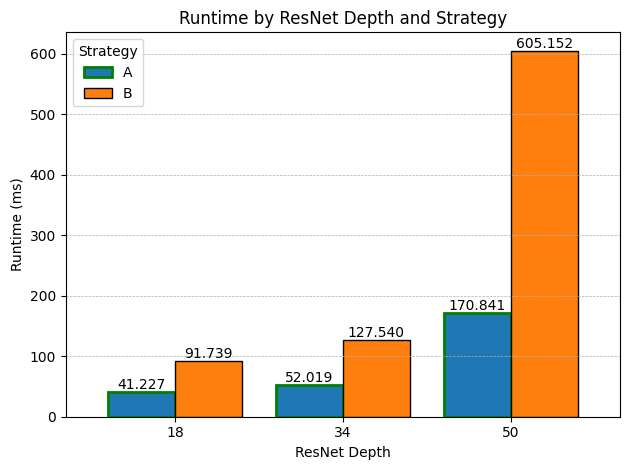

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data creation (you would replace this with your data loading code)

# Pivot the DataFrame to get strategies as columns
pivot_df = df_res_without_unet.pivot(index='model_depth', columns='strat', values='runtime')

# Plotting
ax = pivot_df.plot(kind='bar', width=0.8)

# Highlight the bar with the best IoU by setting the edge color
for i, bar in enumerate(ax.patches):
    if i in [0, 1, 2]:
        bar.set_edgecolor('green')
        bar.set_linewidth(2)  # Adjust border width as needed
    else:
        bar.set_edgecolor('black')  # Set edge color for other bar

plt.xlabel('ResNet Depth')
plt.ylabel('Runtime (ms)')
plt.title('Runtime by ResNet Depth and Strategy')
plt.xticks(rotation=0)  # Rotates labels to be horizontal
plt.legend(title='Strategy')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.5)



# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(f"{round_up_third_decimal(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', rotation=0, xytext=(0, 5),
                textcoords='offset points')

# Show the plot
plt.show()


In [ ]:
df_res.loc[df_res["model_name"] == "ResNet34-U-Net-B"].columns

Index(['model_name', 'overall_iou', 'overall_dice_coefficient', 'mean_iou',
       'mean_dice_coefficient', '0_iou_road', '0_dice_coefficient_road',
       '1_iou_sidewalk', '1_dice_coefficient_sidewalk', '2_iou_human',
       '2_dice_coefficient_human', '3_iou_vehicle',
       '3_dice_coefficient_vehicle', '4_iou_object',
       '4_dice_coefficient_object', '5_iou_construction',
       '5_dice_coefficient_construction', '6_iou_nature',
       '6_dice_coefficient_nature', '7_iou_sky', '7_dice_coefficient_sky',
       'runtime'],
      dtype='object')

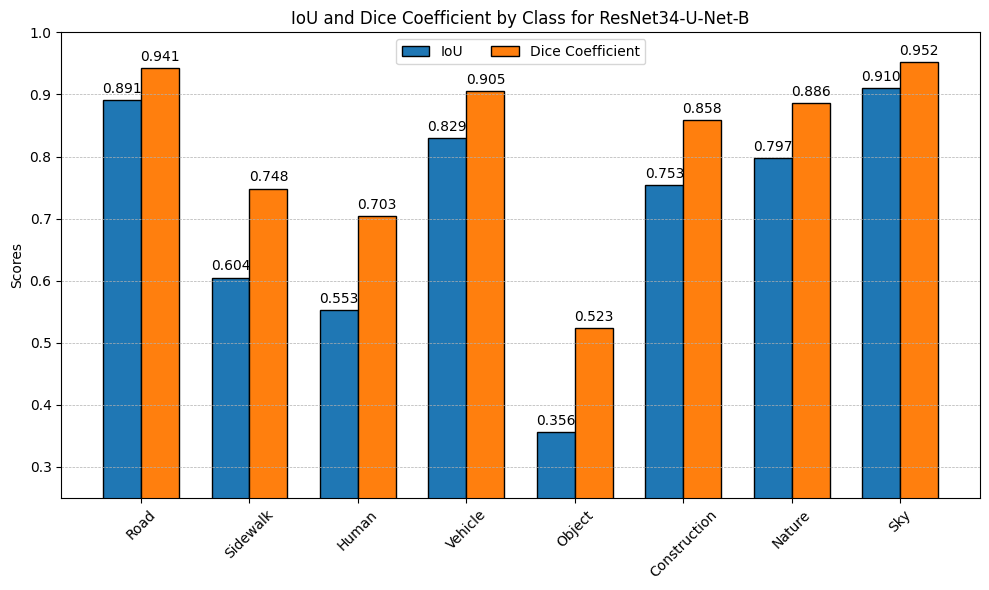

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Assume df_res is your DataFrame already loaded with data
# Filtering the data for the model 'ResNet34-U-Net-B'
data = df_res.loc[df_res["model_name"] == "ResNet34-U-Net-B"]

# Extracting IoU and Dice Coefficients for each class
classes = ['Road', 'Sidewalk', 'Human', 'Vehicle', 'Object', 'Construction', 'Nature', 'Sky']
iou_values = [data[f'{i}_iou_{cls.lower()}'].values[0] for i, cls in enumerate(classes)]
dice_values = [data[f'{i}_dice_coefficient_{cls.lower()}'].values[0] for i, cls in enumerate(classes)]

x = np.arange(len(classes))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, iou_values, width, label='IoU', edgecolor='black')
rects2 = ax.bar(x + width/2, dice_values, width, label='Dice Coefficient', edgecolor='black')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('IoU and Dice Coefficient by Class for ResNet34-U-Net-B')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Function to add labels on the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{truncate_to_three_decimal_places(height)}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

ax.set_ylim(bottom=0.25)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), fancybox=True, ncol=2)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
